# Projeto 7 — Simulação 2D de Difusividade Térmica em Dissipador

## 1. Representação de Números — Conversão em Base 3

Nesta primeira etapa, será realizada a conversão de números representados
em base 3 para valores de temperatura em graus Celsius.

A representação em base 3 utiliza os algarismos 0, 1 e 2. Para realizar
a conversão, será utilizada a expansão definida no projeto:

$$
T = \frac{\sum_{k=0}^{m} d_k 3^k}{2.0}
$$

onde $d_k$ representa cada algarismo do número em base 3 e $k$ representa
a posição do algarismo, iniciando em $k=0$ para o algarismo mais à direita.

A função implementada nesta etapa recebe o número em base 3 como uma
string, realiza a expansão numérica e divide o resultado por 2.0,
obtendo a temperatura correspondente em graus Celsius.

In [ ]:
def base3_to_celsius(b3_str):
    # Inicializa a soma dos valores da representação em base 3
    soma = 0

    # Percorre os dígitos da direita para a esquerda para aplicar 3^k
    for k, digito in enumerate(reversed(b3_str)):
        soma += int(digito) * (3 ** k)

    # Converte o valor decimal obtido para Celsius, dividindo por 2
    return soma / 2.0

In [ ]:
# Testes da função com diferentes valores representados em base 3
resultado1 = base3_to_celsius("102")
resultado2 = base3_to_celsius("10")
resultado3 = base3_to_celsius("222")

print("102₃ =", resultado1, "°C")
print("10₃  =", resultado2, "°C")
print("222₃ =", resultado3, "°C")

102₃ = 5.5 °C
10₃  = 1.5 °C
222₃ = 13.0 °C


### Verificação dos resultados

Os resultados obtidos confirmam a aplicação da expansão em base 3 definida
no projeto.

Para o valor $102_3$:

$$
102_3 = 1\cdot3^2 + 0\cdot3^1 + 2\cdot3^0
$$

$$
102_3 = 9 + 0 + 2 = 11
$$

Aplicando a conversão definida no projeto:

$$
T = \frac{11}{2} = 5,5\ ^\circ C
$$

Os demais testes também apresentaram os resultados esperados, indicando
que a função de conversão foi implementada corretamente.

# 2. Malha de Diferenças Finitas

A superfície do dissipador é representada por uma malha bidimensional
de 5 × 5 nós, totalizando 25 pontos.

As temperaturas dos nós de contorno são conhecidas e representam as
condições de contorno térmicas. Para este projeto, foi adotado o seguinte
perfil:

- Borda superior: 100 °C
- Bordas laterais: 80 °C, 60 °C e 40 °C
- Borda inferior: 20 °C

Nos nós internos é aplicada a Equação de Laplace discretizada pelo
estêncil de cinco pontos:

$$
T_{i+1,j}+T_{i-1,j}+T_{i,j+1}+T_{i,j-1}-4T_{i,j}=0
$$

A partir dessa discretização, será construída a matriz térmica
$A_{térmica}$ de dimensão 25 × 25 e o vetor $b_{térmica}$.

In [ ]:
import numpy as np

# Define uma malha de 5x5 nós, totalizando 25 pontos
n = 5
N = n * n

# Inicializa a matriz do sistema e o vetor das condições de contorno
Atermica = np.zeros((N, N))
btermica = np.zeros(N)

# Define as temperaturas conhecidas nas bordas da malha
temperaturas_contorno = np.array([
    [100, 100, 100, 100, 100],
    [80,   0,   0,   0,  80],
    [60,   0,   0,   0,  60],
    [40,   0,   0,   0,  40],
    [20,  20, 20, 20, 20]
])

# Percorre todos os nós da malha para montar o sistema linear
for i in range(5):
    for j in range(5):

        # Converte a posição (i,j) da malha para o índice do vetor
        k = i * 5 + j

        # Identifica os nós que pertencem às condições de contorno
        if i == 0 or i == 4 or j == 0 or j == 4:

            Atermica[k, k] = 1
            btermica[k] = temperaturas_contorno[i, j]

        else:

            # Aplica o estêncil de cinco pontos da equação de Laplace
            Atermica[k, k] = -4

            # Define os quatro vizinhos diretos do nó atual
            vizinhos = [
                (i - 1, j),
                (i + 1, j),
                (i, j - 1),
                (i, j + 1)
            ]

            # Insere os coeficientes dos vizinhos na matriz
            for ni, nj in vizinhos:

                vizinho = ni * 5 + nj

                # Nós internos recebem coeficiente 1 na matriz
                if ni != 0 and ni != 4 and nj != 0 and nj != 4:
                    Atermica[k, vizinho] = 1

                # Condições de contorno são incorporadas ao vetor b
                else:
                    btermica[k] -= temperaturas_contorno[ni, nj]

# Exibe as dimensões e os valores finais do sistema montado
print("Dimensão da matriz:", Atermica.shape)

print("\nMatriz Atermica:")
print(Atermica)

print("\nVetor btermica:")
print(btermica)

Dimensão da matriz: (25, 25)

Matriz Atermica:
[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -4.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. -4.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1. -4.  0.  0.  0.  0.  1.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0

## 3. Resolução do Sistema Linear por Fatoração LU

Para determinar as temperaturas dos 25 nós, o sistema linear

$$
A_{\text{térmica}}T = b_{\text{térmica}}
$$

é resolvido por meio da Fatoração LU.

A matriz $A_{\text{térmica}}$ é decomposta no produto de duas matrizes:

$$
A_{\text{térmica}} = LU
$$

onde $L$ é uma matriz triangular inferior e $U$ é uma matriz triangular superior.

A resolução é realizada em duas etapas:

$$
Ly = b_{\text{térmica}}
$$

e posteriormente:

$$
UT = y
$$

Assim, obtém-se o vetor $T$ contendo as temperaturas dos 25 nós da malha.

In [ ]:
def fatoracao_lu(A):
    # Obtém a dimensão da matriz do sistema
    n = len(A)

    # Inicializa as matrizes triangular inferior e superior
    L = np.zeros((n, n))
    U = np.zeros((n, n))

    for i in range(n):
        # A diagonal de L é definida como 1
        L[i, i] = 1

        # Calcula os elementos da matriz triangular superior U
        for j in range(i, n):
            soma = 0

            for k in range(i):
                soma += L[i, k] * U[k, j]

            U[i, j] = A[i, j] - soma

        # Calcula os elementos da matriz triangular inferior L
        for j in range(i + 1, n):
            soma = 0

            for k in range(i):
                soma += L[j, k] * U[k, i]

            L[j, i] = (A[j, i] - soma) / U[i, i]

    # Retorna as matrizes da decomposição A = LU
    return L, U


def substituicao_direta(L, b):
    # Resolve o sistema triangular inferior Ly = b
    n = len(b)
    y = np.zeros(n)

    for i in range(n):
        # Calcula a soma dos termos já conhecidos
        soma = 0

        for j in range(i):
            soma += L[i, j] * y[j]

        y[i] = b[i] - soma

    # Retorna o vetor intermediário y
    return y


def substituicao_retroativa(U, y):
    # Resolve o sistema triangular superior UT = y
    n = len(y)
    T = np.zeros(n)

    for i in range(n - 1, -1, -1):
        # Calcula a contribuição dos valores de temperatura já determinados
        soma = 0

        for j in range(i + 1, n):
            soma += U[i, j] * T[j]

        T[i] = (y[i] - soma) / U[i, i]

    # Retorna o vetor final de temperaturas
    return T

# Realiza a decomposição LU da matriz térmica
L, U = fatoracao_lu(Atermica)

# Resolve Ly = b por substituição direta
y = substituicao_direta(L, btermica)

# Resolve UT = y por substituição retroativa
T = substituicao_retroativa(U, y)

print("Temperaturas dos nós:")
print(T)

Temperaturas dos nós:
[100. 100. 100. 100. 100.  80.  80.  80.  80.  80.  60.  60.  60.  60.
  60.  40.  40.  40.  40.  40.  20.  20.  20.  20.  20.]


## 4. Organização das Temperaturas na Malha

O vetor obtido na resolução do sistema contém as temperaturas dos 25 nós da malha.

Para facilitar a interpretação dos resultados, os valores são reorganizados em uma matriz 5×5, mantendo a mesma disposição espacial dos nós.

In [ ]:
# Reorganiza o vetor de 25 temperaturas na forma espacial da malha 5x5
T_malha = T.reshape((5, 5))

print("Distribuição de temperaturas na malha 5x5:")
print(T_malha)

Distribuição de temperaturas na malha 5x5:
[[100. 100. 100. 100. 100.]
 [ 80.  80.  80.  80.  80.]
 [ 60.  60.  60.  60.  60.]
 [ 40.  40.  40.  40.  40.]
 [ 20.  20.  20.  20.  20.]]


## 5. Representação Gráfica da Distribuição de Temperatura

Para facilitar a visualização dos resultados, a distribuição de temperaturas na malha 5×5 será representada graficamente.

O gráfico permite observar a variação da temperatura entre os diferentes nós da malha, destacando as regiões de maior e menor temperatura.

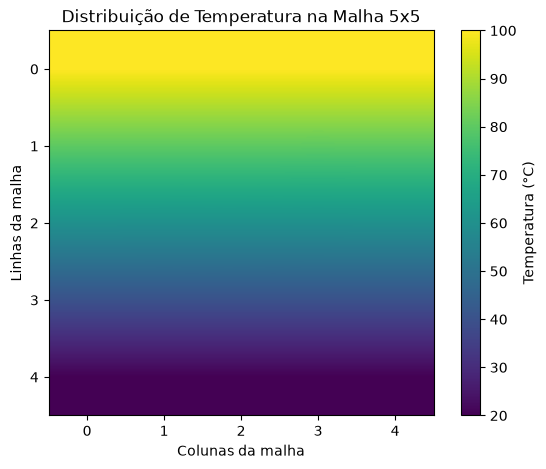

In [ ]:
import matplotlib.pyplot as plt

# Cria a figura para representar a distribuição espacial de temperatura
plt.figure(figsize=(7, 5))

# Exibe a matriz 5x5 como um mapa de temperatura com interpolação bilinear
plt.imshow(T_malha, origin="upper", interpolation="bilinear")

# Adiciona a escala correspondente às temperaturas em graus Celsius
plt.colorbar(label="Temperatura (°C)")

plt.title("Distribuição de Temperatura na Malha 5x5")
plt.xlabel("Colunas da malha")
plt.ylabel("Linhas da malha")

plt.show()

### 5.2. Perfis de Temperatura na Malha

Para analisar a variação da temperatura ao longo das diferentes camadas da malha, são representados os perfis de temperatura de cada linha da matriz 5x5.

Cada curva representa uma camada da malha, permitindo visualizar a distribuição das temperaturas entre as regiões de maior e menor temperatura.

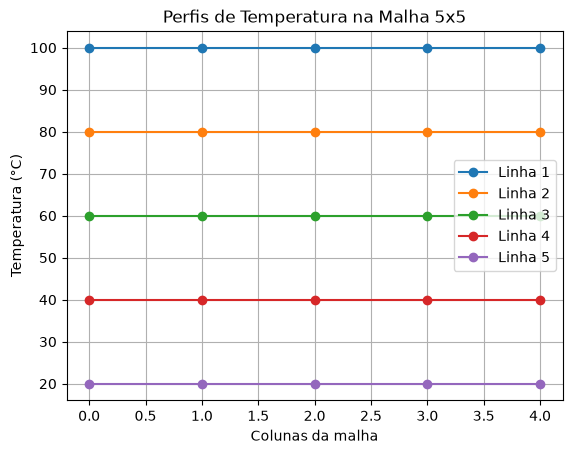

In [ ]:
import matplotlib.pyplot as plt

# Percorre as cinco linhas da malha para representar seus perfis de temperatura
for i in range(5):
    plt.plot(T_malha[i], marker='o', label=f'Linha {i+1}')

plt.title("Perfis de Temperatura na Malha 5x5")
plt.xlabel("Colunas da malha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)

# Exibe os perfis de temperatura das diferentes camadas da malha
plt.show()

## 6. Método Iterativo de Gauss-Seidel

O método de Gauss-Seidel é utilizado para obter uma solução aproximada do sistema linear por meio de iterações sucessivas.

Neste projeto, o método será aplicado ao sistema térmico:

$$
A_{térmica}T = b_{térmica}
$$

A cada iteração, as temperaturas dos nós são atualizadas utilizando os valores mais recentes disponíveis. O processo é repetido até que o erro entre duas iterações consecutivas seja suficientemente pequeno.

A convergência será analisada por meio de um gráfico do erro em função do número de iterações.

In [ ]:
def gauss_seidel(A, b, tol=1e-6, max_iter=10000):
    # Define a dimensão do sistema e inicializa a solução
    n = len(b)
    T = np.zeros(n)
    erros = []

    # Executa o processo iterativo até atingir a tolerância ou o número máximo de iterações
    for k in range(max_iter):
        T_anterior = T.copy()

        # Atualiza cada componente da solução usando o método de Gauss-Seidel
        for i in range(n):
            soma = 0

            # Soma as contribuições dos demais elementos da linha
            for j in range(n):
                if j != i:
                    soma += A[i, j] * T[j]

            # Calcula a nova temperatura usando a equação de Gauss-Seidel
            T[i] = (b[i] - soma) / A[i, i]

        # Calcula o erro máximo entre duas iterações consecutivas
        erro = np.linalg.norm(T - T_anterior, np.inf)
        erros.append(erro)

        # Interrompe o processo quando o erro fica abaixo da tolerância
        if erro < tol:
            break

    # Retorna a solução aproximada e os erros de cada iteração
    return T, erros

# Resolve o sistema térmico pelo método iterativo de Gauss-Seidel
T_gs, erros = gauss_seidel(Atermica, btermica)

print("Temperaturas obtidas pelo método de Gauss-Seidel:")
print(T_gs)

print("\nNúmero de iterações:", len(erros))

Temperaturas obtidas pelo método de Gauss-Seidel:
[100.         100.         100.         100.         100.
  80.          79.99999928  79.99999928  79.99999964  80.
  60.          59.99999928  59.99999928  59.99999964  60.
  40.          39.99999964  39.99999964  39.99999982  40.
  20.          20.          20.          20.          20.        ]

Número de iterações: 27


## 6.1. Convergência do Método de Gauss-Seidel

A convergência do método de Gauss-Seidel pode ser analisada observando a redução do erro a cada iteração.

O gráfico a seguir apresenta o erro máximo entre duas iterações consecutivas em função do número de iterações. Espera-se que o erro diminua progressivamente até atingir a tolerância estabelecida.

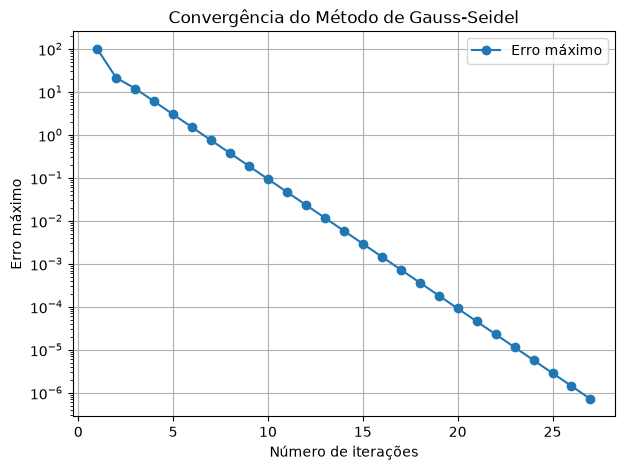

In [ ]:
# Cria o gráfico do erro máximo ao longo das iterações
plt.figure(figsize=(7, 5))

# Representa a redução do erro em escala logarítmica
plt.semilogy(
    range(1, len(erros) + 1),
    erros,
    marker='o',
    label='Erro máximo'
)

plt.title("Convergência do Método de Gauss-Seidel")
plt.xlabel("Número de iterações")
plt.ylabel("Erro máximo")
plt.legend()
plt.grid(True)

plt.show()

## 6.2. Comparação entre os Métodos LU e Gauss-Seidel

A solução obtida pelo método de Gauss-Seidel é comparada com a solução calculada anteriormente pelo método de Fatoração LU.

Os resultados apresentam valores praticamente iguais para as 25 temperaturas da malha. As pequenas diferenças observadas são decorrentes da natureza iterativa do método de Gauss-Seidel e da tolerância utilizada como critério de parada.

Essa comparação permite verificar que o método de Gauss-Seidel convergiu para uma solução compatível com a obtida pela Fatoração LU.

In [ ]:
# Calcula a maior diferença absoluta entre as soluções obtidas por LU e Gauss-Seidel
erro_comparacao = np.linalg.norm(T - T_gs, np.inf)

print("Erro máximo entre LU e Gauss-Seidel:")
print(erro_comparacao)

Erro máximo entre LU e Gauss-Seidel:
7.171183824539185e-07


# 7. Interpretação dos Resultados

A solução numérica permitiu determinar a distribuição de temperatura nos 25 nós da malha 5x5.

Os resultados mostram uma variação gradual da temperatura entre as regiões de maior e menor temperatura, com valores de aproximadamente 100 °C na região superior e 20 °C na região inferior.

A representação gráfica permite visualizar o gradiente de temperatura ao longo da malha, evidenciando a transição progressiva entre as condições de contorno.

O método de Gauss-Seidel também apresentou convergência para uma solução praticamente igual à obtida pela Fatoração LU, com erro máximo da ordem de 10⁻⁷.

Dessa forma, os resultados obtidos são consistentes com o comportamento esperado para o problema de condução de calor analisado.

# 8. Conclusão

A aplicação do método das diferenças finitas permitiu discretizar e resolver numericamente o problema de condução de calor em uma malha de 5x5 nós.

Através da Fatoração LU, foi possível determinar as temperaturas nos 25 nós da malha a partir das condições de contorno estabelecidas.

O método iterativo de Gauss-Seidel também apresentou convergência, obtendo uma solução praticamente igual à calculada pelo método de Fatoração LU. O erro máximo entre os dois métodos foi de aproximadamente 7,17 × 10⁻⁷, confirmando a consistência dos resultados.

A representação gráfica permitiu visualizar o gradiente de temperatura entre as regiões de 100 °C e 20 °C, evidenciando a variação gradual da temperatura na malha.

Dessa forma, o projeto demonstrou a aplicação de métodos numéricos na resolução de um problema de condução de calor, mostrando que tanto a Fatoração LU quanto o método de Gauss-Seidel foram adequados para a obtenção da solução proposta.